# Part 1 - Initial exploration

In [100]:
#import
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, classification_report, confusion_matrix
)

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier

try:
    from xgboost import XGBClassifier
    HAVE_XGB = True
except Exception:
    HAVE_XGB = False

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

CSV_PATH = "secondary_data.csv"  
SEP = ";"                       

all_results = []


#  1. Duplicates

In [101]:
df = pd.read_csv(CSV_PATH, sep=SEP)

dupe = df.duplicated(keep=False).sum()
print("Number of duplicate rows:", dupe)
df = df.drop_duplicates().reset_index(drop=True)

Number of duplicate rows: 266


# 2. Missing values
we decided to remove features that have 70% or more missing values
## 2.1 find the features with most missing values

In [102]:
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
percent = (missing / len(df) * 100)
print("\n\n Number of missing values of each feature and the percent missing: ")
display(pd.DataFrame({'No.': missing, 'Percent': percent}))




 Number of missing values of each feature and the percent missing: 


,No.,Percent
veil-type,57746,94.785221
spore-print-color,54597,89.616401
veil-color,53510,87.832182
stem-root,51536,84.592026
stem-surface,38122,62.574069
gill-spacing,25062,41.137173
cap-surface,14120,23.176797
gill-attachment,9855,16.176157
ring-type,2471,4.055939


## 2.2 Remove features with more than 70% missing values

In [103]:
#drop columns with more than 70% missing vals
df = pd.read_csv(CSV_PATH, sep=SEP)

drop = ["veil-type", "spore-print-color", "veil-color", "stem-root"]
df = df.drop(columns=[c for c in drop if c in df.columns])

# 3. Create train and test sets
Split the data, impute missing values, encode catgorical values, and scale the values  

- Imputing method: mode for categorical columns, mean for numerical columns

- Encoding method: ordinal encoding

- Scaling method: standard scaler

In [104]:
#train test split
y_raw = df["class"].astype(str)
y = y_raw.map({"e": 0, "p": 1}).astype(int)   # 0=edible, 1=poisonous
X = df.drop(columns="class")

X_train_df, X_test_df, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y)

# to fill missing vals, first seperate categorical and numerical cols
cat_cols = X_train_df.select_dtypes(include=["object", "category", "string"]).columns.tolist()
num_cols = X_train_df.select_dtypes(include=["number"]).columns.tolist()

#working on test data only to avoid leakage
#categoorical data
cat_imputer = None
cat_encoder = None
X_train_cat = None
X_test_cat = None

if len(cat_cols) > 0:
    #impute (fill) missing vals with the mode
    cat_imputer = SimpleImputer(strategy="most_frequent")
    X_train_cat_imp = cat_imputer.fit_transform(X_train_df[cat_cols])
    X_test_cat_imp  = cat_imputer.transform(X_test_df[cat_cols])

    #convert categorical data to numerical using ordinal encoding
    cat_encoder = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)
    X_train_cat = cat_encoder.fit_transform(X_train_cat_imp)
    X_test_cat  = cat_encoder.transform(X_test_cat_imp)

#numerical data
num_imputer = None
scaler = None
X_train_num = None
X_test_num = None

if len(num_cols) > 0:
    #impyte using mean
    num_imputer = SimpleImputer(strategy="median")
    X_train_num_imp = num_imputer.fit_transform(X_train_df[num_cols])
    X_test_num_imp  = num_imputer.transform(X_test_df[num_cols])

    #scale using standard scaler
    scaler = StandardScaler(with_mean=True, with_std=True)
    X_train_num = scaler.fit_transform(X_train_num_imp)
    X_test_num  = scaler.transform(X_test_num_imp)

#merge processed blocks into final matrices######################################
def hstack_safe(a, b):
    if a is None and b is None:
        return None
    if a is None:
        return b
    if b is None:
        return a
    return np.hstack([a, b])

X_train = hstack_safe(X_train_cat, X_train_num)
X_test  = hstack_safe(X_test_cat,  X_test_num)

#keep names
feat_names = []
if X_train_cat is not None:
    feat_names += [f"cat_{c}" for c in cat_cols]
if X_train_num is not None:
    feat_names += [f"num_{c}" for c in num_cols]

print(f"Train shape: {X_train.shape}, Test shape: {X_test.shape}")

Train shape: (48855, 16), Test shape: (12214, 16)


In [105]:
#save train and test data
np.savez_compressed(
    "mushroom_train_test.npz",
    X_train=X_train,
    X_test=X_test,
    y_train=y_train,
    y_test=y_test,
    feat_names=np.array(feat_names)
)

print("saved")


saved


# 4. Explore models

## 4.0 Evaluation function
This will be used to analyze models' performance through this section

In [95]:
#evaluation function (will be reerun for each model)
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, accuracy_score, precision_score, recall_score, f1_score
from IPython.display import display
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

def evaluate_and_log(model_name, estimator, X_tr=X_train, X_te=X_test):
    y_pred = estimator.predict(X_te)

    #probability scores for ROC
    if hasattr(estimator, "predict_proba"): #if model accepts probability caluclation, use it
        y_proba = estimator.predict_proba(X_te)[:, 1]
    elif hasattr(estimator, "decision_function"): #otherwise calculate distance from descions boundary (semi probability)
        s = estimator.decision_function(X_te)
        s_min, s_max = s.min(), s.max()
        y_proba = (s - s_min) / (s_max - s_min + 1e-12)
    else: #if model doesnt accept either calculation just use the 1/0 prediction
        y_proba = y_pred.astype(float)

    roc  = roc_auc_score(y_test, y_proba) #use the probability to calculate ROC
    #then do other metrics
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec  = recall_score(y_test, y_pred, zero_division=0)
    f1   = f1_score(y_test, y_pred, zero_division=0)

    print(f"\n=== {model_name} Performance ===")
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall   : {rec:.4f}")
    print(f"F1-score : {f1:.4f}")
    print(f"ROC AUC  : {roc:.4f}\n")

    print("Full Report:\n")
    print(classification_report(y_test, y_pred, target_names=["Edible (0)", "Poisonous (1)"], digits=4))

    cm = confusion_matrix(y_test, y_pred)
    cm_df = pd.DataFrame(cm, index=["True: Edible (0)", "True: Poisonous (1)"],
                         columns=["Pred: Edible (0)", "Pred: Poisonous (1)"])
    print("Confusion Matrix:")

    plt.figure(figsize=(6, 5))
    sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues',
                cbar=False, linewidths=1, linecolor='gray',
                annot_kws={"size": 14, "weight": "bold"})
    plt.title(f"{model_name} - Confusion Matrix", fontsize=14, weight='bold', pad=15)
    plt.xlabel("Predicted Label", fontsize=12)
    plt.ylabel("True Label", fontsize=12)
    plt.xticks(rotation=0)
    plt.yticks(rotation=0)
    plt.show()
    all_results.append({
        "Model": model_name,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1": f1,
        "ROC_AUC": roc,
        "Estimator": estimator,
    })

## 4.1 Logistic Regression



=== Logistic Regression Performance ===
Accuracy : 0.6422
Precision: 0.6516
Recall   : 0.7635
F1-score : 0.7031
ROC AUC  : 0.7008

Full Report:

               precision    recall  f1-score   support

   Edible (0)     0.6248    0.4910    0.5499      5436
Poisonous (1)     0.6516    0.7635    0.7031      6778

     accuracy                         0.6422     12214
    macro avg     0.6382    0.6272    0.6265     12214
 weighted avg     0.6397    0.6422    0.6349     12214

Confusion Matrix:


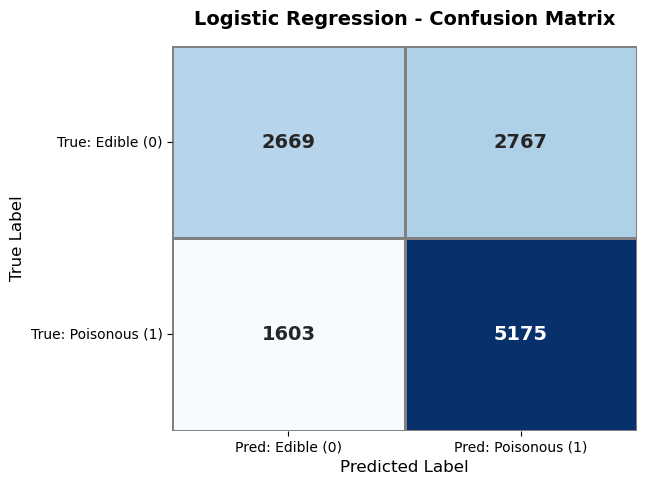

In [97]:
#logistic regression
lr = LogisticRegression(max_iter=500, solver="liblinear", random_state=RANDOM_STATE)
lr.fit(X_train, y_train)
evaluate_and_log("Logistic Regression", lr)


## 4.2 Support vector machine


In [98]:
svm = SVC(kernel="rbf", C=1.0, gamma="scale", probability=True, random_state=RANDOM_STATE)
svm.fit(X_train, y_train)
evaluate_and_log("SVM (RBF)", svm)

NotFittedError: This SVC instance is not fitted yet. Call 'fit' with appropriate arguments before using this estimator.

## 4.3 Multi layer perceptron


=== Neural Network (MLP) Performance ===
Accuracy : 0.9991
Precision: 0.9991
Recall   : 0.9993
F1-score : 0.9992
ROC AUC  : 1.0000

Full Report:

               precision    recall  f1-score   support

   Edible (0)     0.9991    0.9989    0.9990      5436
Poisonous (1)     0.9991    0.9993    0.9992      6778

     accuracy                         0.9991     12214
    macro avg     0.9991    0.9991    0.9991     12214
 weighted avg     0.9991    0.9991    0.9991     12214

Confusion Matrix:


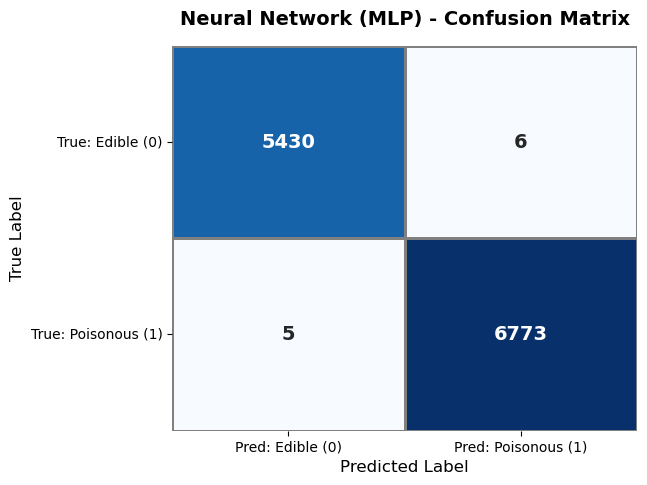

In [11]:
mlp = MLPClassifier(hidden_layer_sizes=(64, 32), alpha=0.0001, max_iter=500, random_state=RANDOM_STATE)
mlp.fit(X_train, y_train)
evaluate_and_log("Neural Network (MLP)", mlp)


## 4.4 Random forest


=== Random Forest Performance ===
Accuracy : 0.9999
Precision: 0.9999
Recall   : 1.0000
F1-score : 0.9999
ROC AUC  : 1.0000

Full Report:

               precision    recall  f1-score   support

   Edible (0)     1.0000    0.9998    0.9999      5436
Poisonous (1)     0.9999    1.0000    0.9999      6749

     accuracy                         0.9999     12185
    macro avg     0.9999    0.9999    0.9999     12185
 weighted avg     0.9999    0.9999    0.9999     12185

Confusion Matrix:


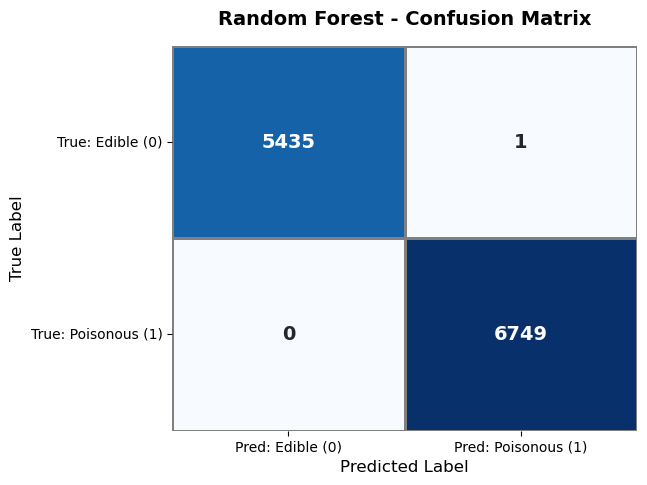

In [59]:
#random forest
rf = RandomForestClassifier(
    n_estimators=200, max_depth=None, random_state=RANDOM_STATE, n_jobs=-1
)
rf.fit(X_train, y_train)
evaluate_and_log("Random Forest", rf)


## 4.5 XGBoost


=== XGBoost Performance ===
Accuracy : 0.9987
Precision: 0.9999
Recall   : 0.9978
F1-score : 0.9988
ROC AUC  : 1.0000

Full Report:

               precision    recall  f1-score   support

   Edible (0)     0.9972    0.9998    0.9985      5436
Poisonous (1)     0.9999    0.9978    0.9988      6778

     accuracy                         0.9987     12214
    macro avg     0.9985    0.9988    0.9987     12214
 weighted avg     0.9987    0.9987    0.9987     12214

Confusion Matrix:


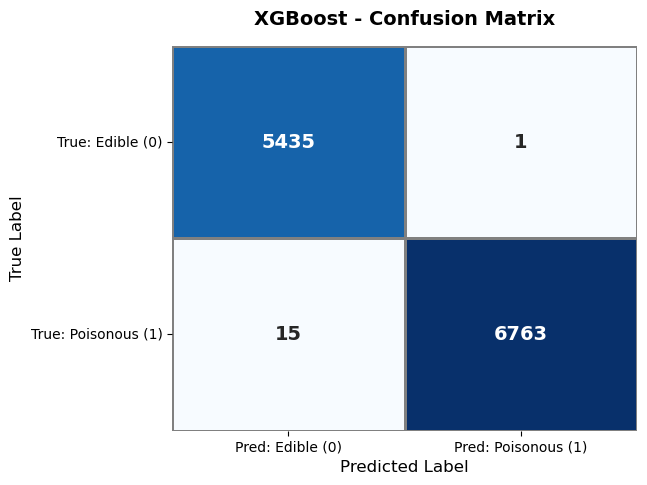

In [13]:
#XGBoost
if HAVE_XGB:
    xgb = XGBClassifier(
        tree_method="hist",
        predictor="auto",
        eval_metric="logloss",
        random_state=RANDOM_STATE,
        n_estimators=300,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8
    )
    xgb.fit(X_train, y_train)
    evaluate_and_log("XGBoost", xgb)
else:
    print("XGBoost not available in this environment.")


# 5. Results Analysis

In [14]:
#comparisn of results

results_df = pd.DataFrame(all_results).sort_values(by="Accuracy", ascending=False)
display(results_df.drop(columns=["Estimator"]).style.hide(axis="index").set_caption("Model Performance Summary"))

best_row = results_df.iloc[0]
print(f"\nBest so far: {best_row['Model']} | "f"Acc {best_row['Accuracy']:.4f} | F1 {best_row['F1']:.4f} | ROC_AUC {best_row['ROC_AUC']:.4f}")


Model,Accuracy,Precision,Recall,F1,ROC_AUC
Random Forest,0.999900,1.000000,0.999900,0.999900,1.000000
Neural Network (MLP),0.999100,0.999100,0.999300,0.999200,1.000000
XGBoost,0.998700,0.999900,0.997800,0.998800,1.000000
SVM (RBF),0.879200,0.894200,0.887400,0.890800,0.946600
Logistic Regression,0.642200,0.651600,0.763500,0.703100,0.700800



Best so far: Random Forest | Acc 0.9999 | F1 0.9999 | ROC_AUC 1.0000


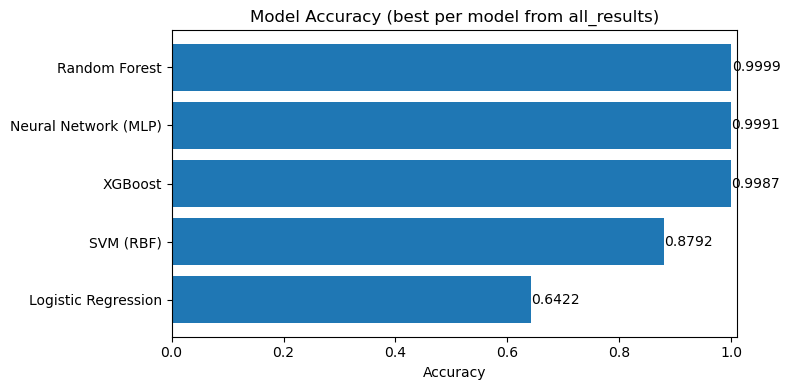

In [22]:
# --- Plot accuracy from your all_results (single-shot runs) ---
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

assert "all_results" in globals() and len(all_results), "Run your model cells first to populate all_results."

acc_df = pd.DataFrame(all_results)[["Model", "Accuracy"]]
acc_df = acc_df.groupby("Model", as_index=False)["Accuracy"].max()  # de-dup if same model logged multiple times

plt.figure(figsize=(8, 4))
order = acc_df.sort_values("Accuracy")  # ascending for nicer bars
plt.barh(order["Model"], order["Accuracy"])
for y, v in enumerate(order["Accuracy"].values):
    plt.text(v + 0.001, y, f"{v:.4f}", va="center")

plt.xlabel("Accuracy")
plt.title("Model Accuracy (best per model from all_results)")
plt.xlim(0, 1.01)
plt.tight_layout()
plt.show()
